In [1]:
import numpy as np

# Problem dimensions
n = 256    # detector pixels
m = 961    # sky pixels

# Convergence parameters
tol  = 1e-5
tfac = 3.0
max_iter = 1000


In [2]:
# Read observed detector plane histogram
dph = np.loadtxt("/home/loney/ml_sky/dph.txt")

# # Add noise and normalize 
# noise = 0.05 * np.random.rand(n)
# dph = dph + noise

sumdph = dph.sum()
dph = dph / dph.sum()


In [3]:
# Read initial sky image
image = np.loadtxt("/home/loney/my_fortran_codes/simulations/SLP/image_file_1.txt")

# Normalize once (initialization)
image = image / image.sum()


In [4]:
shadows = np.zeros((m, n))
shafac  = np.zeros(m)

with open("/home/loney/my_fortran_codes/simulations/SLP/shadow_arrays.txt", "r") as f:
    # Skip first 3 header lines
    for _ in range(3):
        next(f)

    for i in range(m):
        _ = next(f)                         # skip descriptive line
        row = np.fromstring(next(f), sep=' ')
        shadows[i, :] = row
        norm = row.sum()
        shadows[i, :] /= norm
        shafac[i] = 1.0 / norm


In [5]:
maxD = 5.0
itr = 0

while maxD > tol and itr < max_iter:
    itr += 1

    # Build model DPH 
    mdph = np.zeros(n)
    for i in range(m):
        mdph += image[i] * shadows[i, :]

    # Add noise + normalize
    mdph += (0.01 / n) * np.random.rand(n)
    mdph /= mdph.sum()

    # Ratio
    ratio = dph / mdph

    # Backprojection + image update
    correction = np.zeros(m)
    for i in range(m):
        correction[i] = np.sum(ratio * shadows[i, :])
        image[i] *= correction[i]

    # Normalize image
    image /= image.sum()

    # Thresholded convergence test
    mean = image.mean()
    rms  = np.sqrt(np.mean((image - mean)**2))
    thresh = tfac * rms + mean

    D = np.zeros(m)
    strong = image > thresh
    D[strong] = np.abs(1.0 - correction[strong])

    maxD = D.max()

    print(f"Iteration {itr:4d}   max|1-Ci| = {maxD:.6e}")


Iteration    1   max|1-Ci| = 2.133069e+00
Iteration    2   max|1-Ci| = 1.061325e+00
Iteration    3   max|1-Ci| = 7.956665e-01
Iteration    4   max|1-Ci| = 6.478738e-01
Iteration    5   max|1-Ci| = 5.350061e-01
Iteration    6   max|1-Ci| = 4.916170e-01
Iteration    7   max|1-Ci| = 4.527811e-01
Iteration    8   max|1-Ci| = 4.158190e-01
Iteration    9   max|1-Ci| = 3.779483e-01
Iteration   10   max|1-Ci| = 3.393648e-01
Iteration   11   max|1-Ci| = 2.998562e-01
Iteration   12   max|1-Ci| = 2.629632e-01
Iteration   13   max|1-Ci| = 2.273851e-01
Iteration   14   max|1-Ci| = 1.949474e-01
Iteration   15   max|1-Ci| = 1.654626e-01
Iteration   16   max|1-Ci| = 1.402329e-01
Iteration   17   max|1-Ci| = 1.183407e-01
Iteration   18   max|1-Ci| = 1.000895e-01
Iteration   19   max|1-Ci| = 8.458005e-02
Iteration   20   max|1-Ci| = 7.156599e-02
Iteration   21   max|1-Ci| = 6.091663e-02
Iteration   22   max|1-Ci| = 5.174238e-02
Iteration   23   max|1-Ci| = 4.475791e-02
Iteration   24   max|1-Ci| = 3.811

In [6]:
# Save sky profile
np.savetxt("sky_profile.txt",
           np.column_stack((np.arange(0, m), image)),
           fmt="%5d %14.8e")

# Convert to physical intensity (same scaling as your F90 code)
final_image = image * sumdph * shafac

np.savetxt("final_image.txt",
           np.column_stack((np.arange(0, m), final_image)),
           fmt="%5d %14.8e")


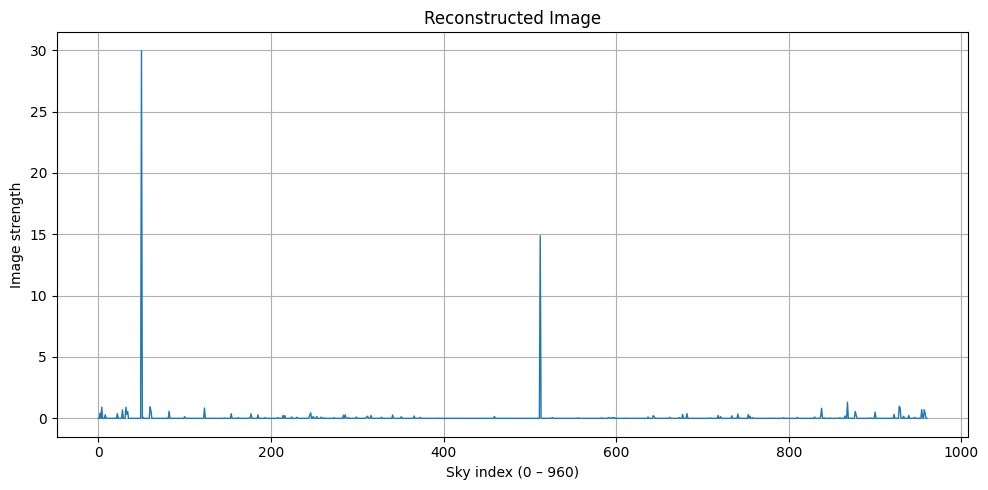

In [7]:
import matplotlib.pyplot as plt

# Load the final image file
data = np.loadtxt("final_image.txt")

index = data[:, 0]
strength = data[:, 1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(index, strength, lw=1)

plt.xlabel("Sky index (0 – 960)")
plt.ylabel("Image strength")
plt.title("Reconstructed Image")

plt.grid(True)
plt.tight_layout()
plt.show()
